# 01 - 形态策略研究与回测

策略思路：根据K线形态（吞没形态 + 20日突破）买卖，支持选择股票与回测时间段。

In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
for p in [cwd / 'src', cwd.parent / 'src']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from quant_research.db import query_df

In [9]:
symbol = 'US:AAPL'
start_date = '2025-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
fee_rate = 0.0003
slippage = 0.001

In [10]:
df = query_df(f"""
select trade_date, symbol, open, high, low, close, volume
from daily_bars
where symbol = '{symbol}'
  and trade_date between toDate('{start_date}') and toDate('{end_date}')
order by trade_date
""")
df['trade_date'] = pd.to_datetime(df['trade_date'])
df.head()

,trade_date,symbol,open,high,low,close,volume
0,2025-01-02,US:AAPL,247.577564,247.746654,240.506207,242.525177,55740700.0
1,2025-01-03,US:AAPL,242.037827,242.853364,240.575812,242.037827,40244100.0
2,2025-01-06,US:AAPL,242.982676,245.986273,241.878706,243.668930,45045600.0
3,2025-01-07,US:AAPL,241.659879,244.215924,240.038745,240.894073,40856000.0
4,2025-01-08,US:AAPL,240.605648,242.385931,238.745812,241.381409,37628900.0


In [11]:
def add_pattern_signal(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out['ma20'] = out['close'].rolling(20).mean()
    out['high20'] = out['high'].rolling(20).max()

    prev_open = out['open'].shift(1)
    prev_close = out['close'].shift(1)

    bullish_engulf = (prev_close < prev_open) & (out['close'] > out['open']) & (out['open'] < prev_close) & (out['close'] > prev_open)
    bearish_engulf = (prev_close > prev_open) & (out['close'] < out['open']) & (out['open'] > prev_close) & (out['close'] < prev_open)

    breakout_buy = out['close'] > out['high20'].shift(1)
    ma_sell = out['close'] < out['ma20']

    out['buy_signal'] = (bullish_engulf | breakout_buy).astype(int)
    out['sell_signal'] = (bearish_engulf | ma_sell).astype(int)
    return out


def backtest(data: pd.DataFrame, fee_rate: float, slippage: float) -> tuple[pd.DataFrame, dict]:
    out = add_pattern_signal(data).copy()
    out['ret'] = out['close'].pct_change().fillna(0.0)

    pos = np.zeros(len(out), dtype=int)
    for i in range(1, len(out)):
        pos[i] = pos[i - 1]
        if out['buy_signal'].iat[i] == 1:
            pos[i] = 1
        if out['sell_signal'].iat[i] == 1:
            pos[i] = 0

    out['position'] = pd.Series(pos, index=out.index).shift(1).fillna(0).astype(int)
    out['trade_flag'] = out['position'].diff().abs().fillna(0)
    cost = out['trade_flag'] * (fee_rate + slippage)

    out['strategy_ret'] = out['position'] * out['ret'] - cost
    out['strategy_curve'] = (1 + out['strategy_ret']).cumprod()
    out['benchmark_curve'] = (1 + out['ret']).cumprod()

    days = max(len(out), 1)
    ann_factor = 252 / days
    total_return = out['strategy_curve'].iat[-1] - 1
    cagr = (1 + total_return) ** ann_factor - 1
    mdd = (out['strategy_curve'] / out['strategy_curve'].cummax() - 1).min()
    sharpe = np.sqrt(252) * out['strategy_ret'].mean() / (out['strategy_ret'].std() + 1e-12)

    metrics = {
        'total_return': float(total_return),
        'cagr': float(cagr),
        'max_drawdown': float(mdd),
        'sharpe': float(sharpe),
        'num_trades': int(out['trade_flag'].sum()),
    }
    return out, metrics

In [12]:
bt, metrics = backtest(df, fee_rate=fee_rate, slippage=slippage)
pd.DataFrame([{'symbol': symbol, **metrics}])

,symbol,total_return,cagr,max_drawdown,sharpe,num_trades
0,US:AAPL,-0.141222,-0.118931,-0.18791,-0.806449,20


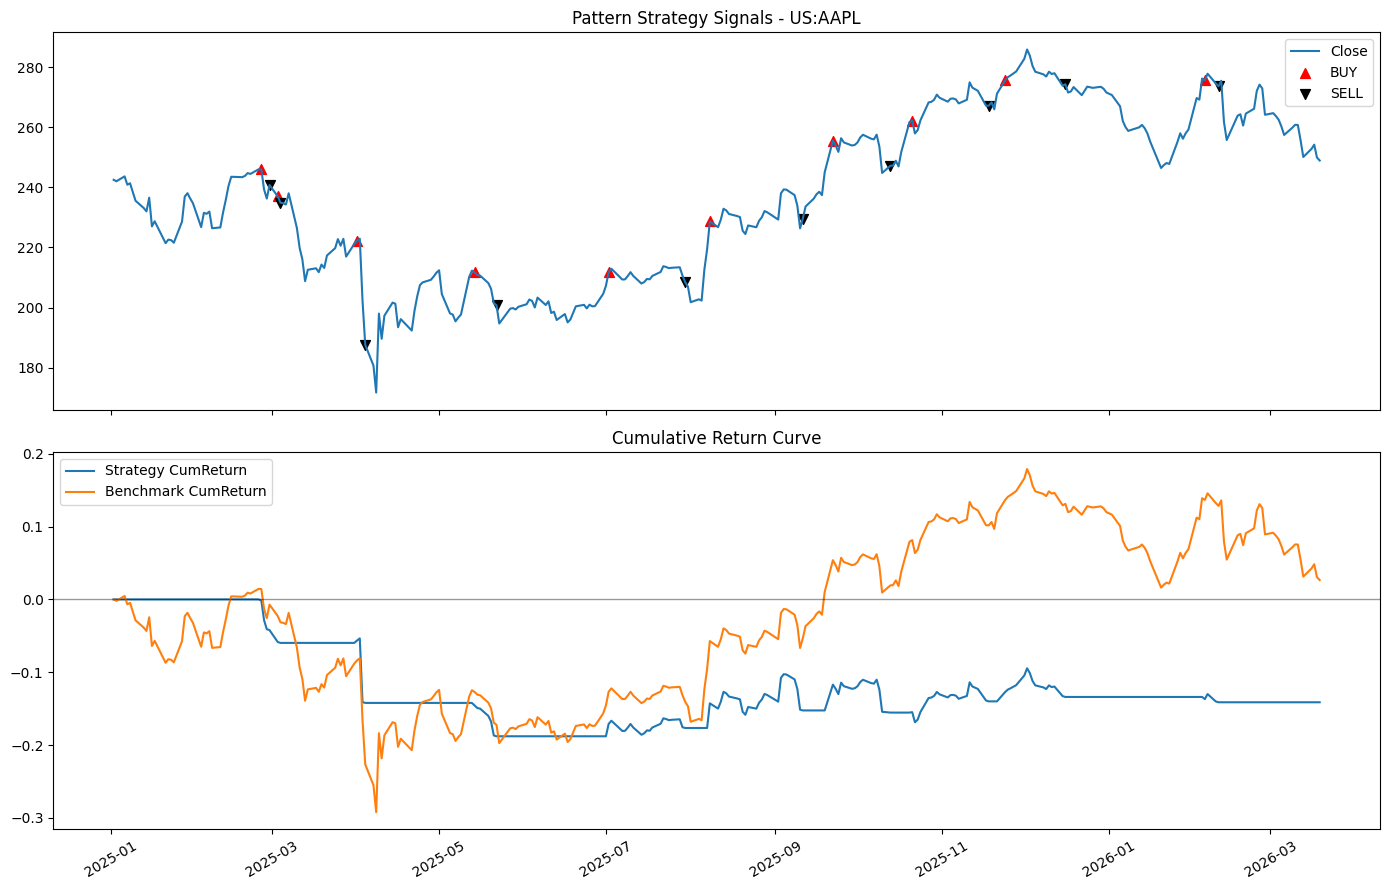

In [13]:
buy_pts = bt[(bt['position'].diff() > 0).fillna(False)]
sell_pts = bt[(bt['position'].diff() < 0).fillna(False)]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(bt['trade_date'], bt['close'], label='Close')
axes[0].scatter(buy_pts['trade_date'], buy_pts['close'], marker='^', color='red', s=50, label='BUY')
axes[0].scatter(sell_pts['trade_date'], sell_pts['close'], marker='v', color='black', s=50, label='SELL')
axes[0].set_title(f'Pattern Strategy Signals - {symbol}')
axes[0].legend()

axes[1].plot(bt['trade_date'], bt['strategy_curve'] - 1, label='Strategy CumReturn')
axes[1].plot(bt['trade_date'], bt['benchmark_curve'] - 1, label='Benchmark CumReturn')
axes[1].axhline(0, color='black', linewidth=1, alpha=0.4)
axes[1].set_title('Cumulative Return Curve')
axes[1].legend()

plt.xticks(rotation=30)
plt.tight_layout()